# Few dimensions analysis


## CIFAR10

In [8]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader    
import os
import sys
sys.path.append(os.path.abspath(".."))

from analysis.viz import visualize_3d, tsne_3d
from metrics.retrieval import compute_retrieval
from dataset.cifar10.cifar10_dataloader_with_labels import EmbeddingsDatasetWithLabels as EmbeddingsDatasetWithLabelsCifar
from dataset.cifar10.cifar10_dataloader_with_labels import make_loaders_cifar10

import torch.nn.functional as F
import torch 
import torch.nn as nn
import wandb
import copy
from torch.nn.utils import clip_grad_norm_
# Add parent directory to Python path so we can import `models.*`
seed = 123
g = torch.Generator().manual_seed(seed)

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from subspace_alignment.subspace_alignment import fit_subspace_alignment, apply_subspace_alignment, eval_subspace_alignment_mscoco, analyze_subspace_dimensions
import matplotlib.pyplot as plt



In [2]:
# Define constants
dataset = "cifar10"  # or "flickr30k"
precomputed_train_dir = "/mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_train_ViT-B-32_laion2b_s34b_b79k"
precomputed_test_dir = "/mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_test_ViT-B-32_laion2b_s34b_b79k"
device = "cuda:3" if torch.cuda.is_available() else "cpu"

In [3]:
train_loader, test_loader = make_loaders_cifar10(batch_size=256, precomputed_train_dir=precomputed_train_dir, precomputed_test_dir=precomputed_test_dir, seed=0, num_workers=0)

[Loaded] 50000 samples from /mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_train_ViT-B-32_laion2b_s34b_b79k | text_emb shape=(50000, 512)
[Loaded] 10000 samples from /mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_test_ViT-B-32_laion2b_s34b_b79k | text_emb shape=(10000, 512)


In [4]:
#Let's get it from the training set, since it contains more samples per class and thus the average embedding will be more stable
label_to_embedding = {}
with torch.no_grad():
    for text_b, vis_b, labels in tqdm(train_loader, desc="Building label_to_embedding dict"):
        for text_emb, vis_emb, label in zip(text_b, vis_b, labels):
            label = label.item()
            if label not in label_to_embedding:
                label_to_embedding[label] = {"text": []}
                label_to_embedding[label] = text_emb

Building label_to_embedding dict: 100%|██████████| 196/196 [00:00<00:00, 293.53it/s]


In [5]:
def normalize01(v, eps=1e-12):
    v = v.astype(np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def get_dims_gap(loader, max_samples=20_000, device='cuda'):
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b, _ in tqdm(loader, desc=f"Collecting {max_samples} pairs"):
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()
            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break
    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]

    muX = X.mean(axis=0)  # (D,)
    muY = Y.mean(axis=0)  # (D,)

    gap_dim = np.abs(muX - muY) 
    top_gap = np.argsort(-gap_dim)

    return normalize01(gap_dim), top_gap

In [10]:
d_sub = 256
sub_model = fit_subspace_alignment(train_loader, d_sub=256)
important_dims_txt, important_dims_img, important_joint_dims = analyze_subspace_dimensions(sub_model, device="cuda")
gap_dims, top_gap_idx = get_dims_gap(train_loader)

Collected 10000 samples of dimension 512, these will be used to fit the subspace alignment model with d_sub=256.


In [ ]:
from subspace_alignment.subspace_alignment import fit_subspace_alignment, apply_subspace_alignment, analyze_subspace_dimensions, eval_subspace_alignment_cifar10
eval_subspace_alignment_cifar10(test_loader, sub_model, labels_to_emb=label_to_embedding)

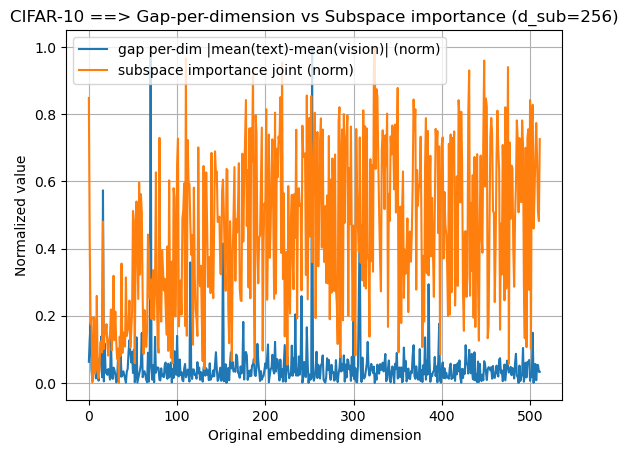

In [12]:
plt.plot(gap_dims, label="gap per-dim |mean(text)-mean(vision)| (norm)")
plt.plot(important_joint_dims, label="subspace importance joint (norm)")
plt.title(f"CIFAR-10 ==> Gap-per-dimension vs Subspace importance (d_sub={d_sub})")
plt.xlabel("Original embedding dimension")
plt.ylabel("Normalized value")
plt.grid(True)
plt.legend()
plt.show()

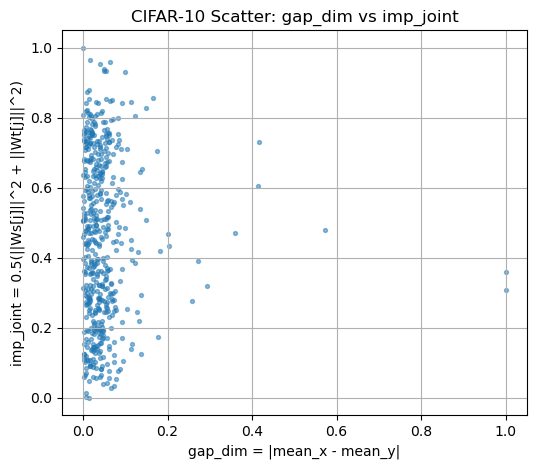

In [14]:
plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.5)
plt.title(f"CIFAR-10 Scatter: gap_dim vs imp_joint")
plt.xlabel("gap_dim = |mean_x - mean_y|")
plt.ylabel("imp_joint = 0.5(||Ws[j]||^2 + ||Wt[j]||^2)")
plt.grid(True)
plt.show()

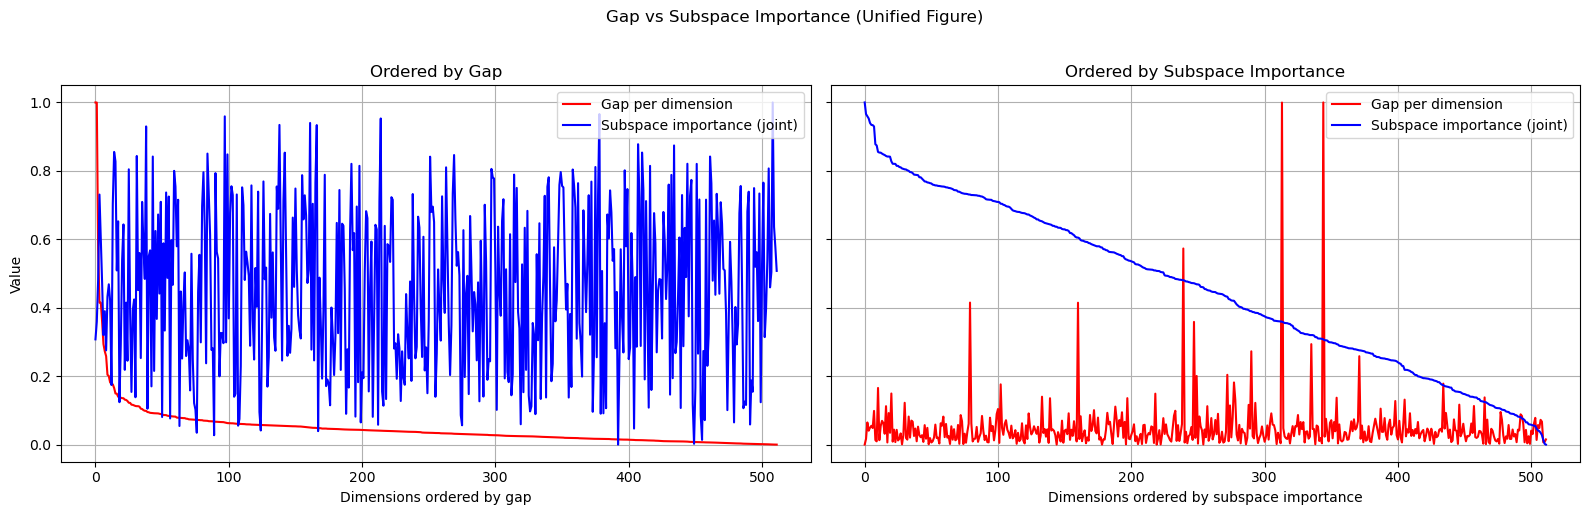

In [16]:
def plot_gap_importance_unified(analysis):
    gap_dim = analysis["gap_dim"]
    imp_joint = analysis["imp_joint"]

    # Orders
    order_gap = np.argsort(-gap_dim)
    order_imp = np.argsort(-imp_joint)

    # Sorted values
    gap_by_gap = gap_dim[order_gap]
    imp_by_gap = imp_joint[order_gap]

    gap_by_imp = gap_dim[order_imp]
    imp_by_imp = imp_joint[order_imp]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    # Left: ordered by gap
    axes[0].plot(gap_by_gap, label="Gap per dimension", color="red")
    axes[0].plot(imp_by_gap, label="Subspace importance (joint)", color="blue")
    axes[0].set_title("Ordered by Gap")
    axes[0].set_xlabel("Dimensions ordered by gap")
    axes[0].set_ylabel("Value")
    axes[0].grid(True)
    axes[0].legend()

    # Right: ordered by importance
    axes[1].plot(gap_by_imp, label="Gap per dimension", color="red")
    axes[1].plot(imp_by_imp, label="Subspace importance (joint)", color="blue")
    axes[1].set_title("Ordered by Subspace Importance")
    axes[1].set_xlabel("Dimensions ordered by subspace importance")
    axes[1].grid(True)
    axes[1].legend()

    plt.suptitle("Gap vs Subspace Importance (Unified Figure)", y=1.02)
    plt.tight_layout()
    plt.show()


analysis = {
    'gap_dim' : gap_dims,
    'imp_joint' : important_joint_dims
}
plot_gap_importance_unified(analysis)

### Ablation on thresholds selection

In [ ]:
import math
try:
    import optuna
except ImportError as exc:
    raise ImportError(
        "optuna is required for Bayesian search. Install with: pip install optuna"
    ) from exc

from analysis.modality_gap import compute_gap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    v_measure_score,
)
CIFAR_SEARCH_CFG = {
    "n_trials": 100,
    "seed": 0,
    "max_eval_batches": 40,
    "max_cluster_samples": 3000,
    "min_dims": 16,
    "direction": "text_to_vision",
    "n_clusters": 10,
}

In [45]:

def _select_dims(imp, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((imp >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-imp)
        idx = order[:min_dims]
    return np.sort(idx)

def _to_scalar(v):
    if isinstance(v, dict):
        v = v.get("text_vision", next(iter(v.values())))
    if torch.is_tensor(v):
        v = v.item()
    return float(v)

def _clustering_metrics_two_modalities(X, Y, labels, n_clusters=10, random_state=0):
    X_np = X.detach().cpu().numpy()
    Y_np = Y.detach().cpu().numpy()
    if torch.is_tensor(labels):
        L_np = labels.detach().cpu().numpy()
    else:
        L_np = np.asarray(labels)

    emb = np.vstack([X_np, Y_np])
    true2 = np.concatenate([L_np, L_np], axis=0)

    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    pred = km.fit_predict(emb)

    return {
        "ARI": adjusted_rand_score(true2, pred),
        "NMI": normalized_mutual_info_score(true2, pred),
        "Homogeneity": homogeneity_score(true2, pred),
        "V-measure": v_measure_score(true2, pred),
        "cluster_labels": pred,
        "true_labels_2N": true2,
        "emb_2N": emb,
    }

def _plot_pca_2d(emb_2N, labels_2N, title, max_points=6000):
    n2 = emb_2N.shape[0]
    n = n2 // 2
    modality = np.concatenate([
        np.zeros(n, dtype=np.int32),
        np.ones(n2 - n, dtype=np.int32),
    ])

    if n2 > max_points:
        idx = np.random.RandomState(0).choice(n2, size=max_points, replace=False)
        emb_2N = emb_2N[idx]
        labels_2N = labels_2N[idx]
        modality = modality[idx]

    z = PCA(n_components=2, random_state=0).fit_transform(emb_2N)

    plt.figure(figsize=(6, 5))
    plt.scatter(
        z[modality == 1, 0], z[modality == 1, 1],
        c=labels_2N[modality == 1], cmap="tab10", s=18, alpha=0.6, marker="o", label="vision"
    )
    plt.scatter(
        z[modality == 0, 0], z[modality == 0, 1],
        c=labels_2N[modality == 0], cmap="tab10", s=18, alpha=0.8, marker="x", label="text"
    )
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

def eval_thresholds_cifar10(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    label_to_embedding,
    device="cuda",
    max_eval_batches=None,
    max_cluster_samples=3000,
    n_clusters=10,
    direction="text_to_vision",
    min_dims=16,
):
    idx = _select_dims(important_joint_dims, gap_dims, imp_thr, gap_thr, min_dims=min_dims)

    r_orig = {1: [], 5: [], 10: []}
    r_al = {1: [], 5: [], 10: []}
    gaps = ["RMG", "L2M", "L2I", "cosineTP"]
    gaps_orig_batches = {g: [] for g in gaps}
    gaps_al_batches = {g: [] for g in gaps}

    Xt_buf, Xv_buf, Xt_al_buf, Xv_al_buf, y_buf = [], [], [], [], []
    seen = 0
    n_batches = 0

    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(test_loader, desc="Eval thresholds CIFAR10"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)
            labels = labels.to(device)

            Xs = X[:, idx]
            Ys = Y[:, idx]
            label_to_embedding_sel = {
               k: v.to(X.device)[idx] for k, v in label_to_embedding.items()
            }

            inputs = (Xs, Ys, labels) if direction == "text_to_vision" else (Ys, Xs, labels)
            r_orig[1].append(_to_scalar(compute_retrieval("cifar10", inputs, top_k=1, labels_to_emb=label_to_embedding_sel)))
            r_orig[5].append(_to_scalar(compute_retrieval("cifar10", inputs, top_k=5, labels_to_emb=label_to_embedding_sel)))
            r_orig[10].append(_to_scalar(compute_retrieval("cifar10", inputs, top_k=10, labels_to_emb=label_to_embedding_sel)))

            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, sub_model, renorm=True)
            Xal_s = Xn[:, idx]
            Yal_s = Yaln[:, idx]

            inputs_al = (Xal_s, Yal_s, labels) if direction == "text_to_vision" else (Yal_s, Xal_s, labels)
            r_al[1].append(_to_scalar(compute_retrieval("cifar10", inputs_al, top_k=1, labels_to_emb=label_to_embedding_sel)))
            r_al[5].append(_to_scalar(compute_retrieval("cifar10", inputs_al, top_k=5, labels_to_emb=label_to_embedding_sel)))
            r_al[10].append(_to_scalar(compute_retrieval("cifar10", inputs_al, top_k=10, labels_to_emb=label_to_embedding_sel)))

            for gname in gaps:
                go = compute_gap(gname, Xs, Ys, iterations=None)
                ga = compute_gap(gname, Xal_s, Yal_s, iterations=None)
                gaps_orig_batches[gname].append(_to_scalar(go))
                gaps_al_batches[gname].append(_to_scalar(ga))

            if seen < max_cluster_samples:
                b = min(Xs.shape[0], max_cluster_samples - seen)
                Xt_buf.append(Xs[:b].detach().cpu())
                Xv_buf.append(Ys[:b].detach().cpu())
                Xt_al_buf.append(Xal_s[:b].detach().cpu())
                Xv_al_buf.append(Yal_s[:b].detach().cpu())
                y_buf.append(labels[:b].detach().cpu())
                seen += b

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    gaps_orig = {g: float(np.mean(v)) for g, v in gaps_orig_batches.items()}
    gaps_al = {g: float(np.mean(v)) for g, v in gaps_al_batches.items()}

    metrics = {
        "n_dims": int(idx.size),
        "dim_idx": idx,
        "retrieval_orig": {k: float(np.mean(v)) for k, v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k, v in r_al.items()},
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_al,
    }

    if len(Xt_buf) > 0:
        Xt_all = torch.cat(Xt_buf, dim=0)
        Xv_all = torch.cat(Xv_buf, dim=0)
        Xt_al_all = torch.cat(Xt_al_buf, dim=0)
        Xv_al_all = torch.cat(Xv_al_buf, dim=0)
        y_all = torch.cat(y_buf, dim=0)

        if direction == "text_to_vision":
            cluster_orig = _clustering_metrics_two_modalities(
                Xt_all, Xv_all, y_all, n_clusters=n_clusters, random_state=0
            )
            cluster_al = _clustering_metrics_two_modalities(
                Xt_al_all, Xv_al_all, y_all, n_clusters=n_clusters, random_state=0
            )
        else:
            cluster_orig = _clustering_metrics_two_modalities(
                Xv_all, Xt_all, y_all, n_clusters=n_clusters, random_state=0
            )
            cluster_al = _clustering_metrics_two_modalities(
                Xv_al_all, Xt_al_all, y_all, n_clusters=n_clusters, random_state=0
            )

        metrics["clustering_orig"] = {
            k: cluster_orig[k]
            for k in ["ARI", "NMI", "Homogeneity", "V-measure"]
        }
        metrics["clustering_aligned"] = {
            k: cluster_al[k]
            for k in ["ARI", "NMI", "Homogeneity", "V-measure"]
        }
    else:
        metrics["clustering_orig"] = None
        metrics["clustering_aligned"] = None

    return metrics

def objective_cifar10(trial):
    imp_thr = trial.suggest_float("imp_thr", 0.0, 1.0)
    gap_thr = trial.suggest_float("gap_thr", 0.0, 1.0)

    metrics = eval_thresholds_cifar10(
        imp_thr,
        gap_thr,
        test_loader,
        sub_model,
        label_to_embedding=label_to_embedding,
        device=device,
        max_eval_batches=CIFAR_SEARCH_CFG["max_eval_batches"],
        max_cluster_samples=CIFAR_SEARCH_CFG["max_cluster_samples"],
        n_clusters=CIFAR_SEARCH_CFG["n_clusters"],
        direction=CIFAR_SEARCH_CFG["direction"],
        min_dims=CIFAR_SEARCH_CFG["min_dims"],
    )

    r_orig = metrics["retrieval_orig"][1]
    r_al = metrics["retrieval_aligned"][1]
    v_orig = metrics["clustering_orig"]["V-measure"] if metrics["clustering_orig"] else 0.0
    v_al = metrics["clustering_aligned"]["V-measure"] if metrics["clustering_aligned"] else 0.0

    score = 0.5 * (r_orig + r_al) + 0.5 * (v_orig + v_al)
    trial.set_user_attr("metrics", metrics)
    trial.set_user_attr("score_terms", {"r_orig": r_orig, "r_al": r_al, "v_orig": v_orig, "v_al": v_al})
    return score

sampler = optuna.samplers.TPESampler(seed=CIFAR_SEARCH_CFG["seed"])
study_cifar10 = optuna.create_study(direction="maximize", sampler=sampler)
study_cifar10.optimize(objective_cifar10, n_trials=CIFAR_SEARCH_CFG["n_trials"])

best_cifar10 = study_cifar10.best_trial
best_metrics_cifar10 = best_cifar10.user_attrs["metrics"]

print("Best thresholds (CIFAR10):")
print(f"  imp_thr={best_cifar10.params['imp_thr']:.4f} | gap_thr={best_cifar10.params['gap_thr']:.4f}")
print(f"  n_dims={best_metrics_cifar10['n_dims']}")
print("Best metrics (retrieval@1):")
print(f"  orig={best_metrics_cifar10['retrieval_orig'][1]:.4f} | aligned={best_metrics_cifar10['retrieval_aligned'][1]:.4f}")
if best_metrics_cifar10["clustering_orig"]:
    print("Best metrics (V-measure):")
    print(
        f"  orig={best_metrics_cifar10['clustering_orig']['V-measure']:.4f} | "
        f"aligned={best_metrics_cifar10['clustering_aligned']['V-measure']:.4f}"
    )
print("Best gaps (orig):", best_metrics_cifar10["gaps_orig"])
print("Best gaps (aligned):", best_metrics_cifar10["gaps_aligned"])

top_cifar10 = sorted(study_cifar10.trials, key=lambda t: t.value, reverse=True)[:5]
for i, t in enumerate(top_cifar10, 1):
    m = t.user_attrs["metrics"]
    print(
        f"Top {i}: score={t.value:.4f} imp={t.params['imp_thr']:.3f} gap={t.params['gap_thr']:.3f} "
        f"dims={m['n_dims']} r1_o={m['retrieval_orig'][1]:.4f} r1_a={m['retrieval_aligned'][1]:.4f} "
        f"v_o={m['clustering_orig']['V-measure'] if m['clustering_orig'] else 0.0:.4f} "
        f"v_a={m['clustering_aligned']['V-measure'] if m['clustering_aligned'] else 0.0:.4f}"
    )


[I 2026-03-10 19:49:22,885] A new study created in memory with name: no-name-80635395-4079-44ff-a1ff-9ec5f2241b3a
Eval thresholds CIFAR10:  98%|█████████▊| 39/40 [00:04<00:00,  9.10it/s]
[I 2026-03-10 19:49:27,239] Trial 0 finished with value: 1.4522579858525702 and parameters: {'imp_thr': 0.5488135039273248, 'gap_thr': 0.7151893663724195}. Best is trial 0 with value: 1.4522579858525702.
Eval thresholds CIFAR10:  98%|█████████▊| 39/40 [00:04<00:00,  9.17it/s]
[I 2026-03-10 19:49:31,556] Trial 1 finished with value: 1.4532574717692501 and parameters: {'imp_thr': 0.6027633760716439, 'gap_thr': 0.5448831829968969}. Best is trial 1 with value: 1.4532574717692501.
Eval thresholds CIFAR10:  98%|█████████▊| 39/40 [00:04<00:00,  8.80it/s]
[I 2026-03-10 19:49:36,083] Trial 2 finished with value: 1.487793881817285 and parameters: {'imp_thr': 0.4236547993389047, 'gap_thr': 0.6458941130666561}. Best is trial 2 with value: 1.487793881817285.
Eval thresholds CIFAR10:  98%|█████████▊| 39/40 [00:04<00

Best thresholds (CIFAR10):
  imp_thr=0.1271 | gap_thr=0.2291
  n_dims=454
Best metrics (retrieval@1):
  orig=1.0000 | aligned=1.0000
Best metrics (V-measure):
  orig=0.5770 | aligned=0.5974
Best gaps (orig): {'RMG': 0.8219249580904935, 'L2M': 0.5070696920156479, 'L2I': 0.8827739536762238, 'cosineTP': 0.23785953596234322}
Best gaps (aligned): {'RMG': 0.8332673774425807, 'L2M': 0.6200122937560082, 'L2I': 0.9337789744138718, 'cosineTP': 0.20110847568139434}
Top 1: score=1.5872 imp=0.127 gap=0.229 dims=454 r1_o=1.0000 r1_a=1.0000 v_o=0.5770 v_a=0.5974
Top 2: score=1.5813 imp=0.113 gap=0.544 dims=469 r1_o=1.0000 r1_a=1.0000 v_o=0.6291 v_a=0.5334
Top 3: score=1.5686 imp=0.137 gap=0.656 dims=458 r1_o=1.0000 r1_a=1.0000 v_o=0.6325 v_a=0.5047
Top 4: score=1.5644 imp=0.188 gap=0.082 dims=376 r1_o=1.0000 r1_a=1.0000 v_o=0.6730 v_a=0.4558
Top 5: score=1.5619 imp=0.217 gap=0.047 dims=260 r1_o=1.0000 r1_a=1.0000 v_o=0.7103 v_a=0.4134


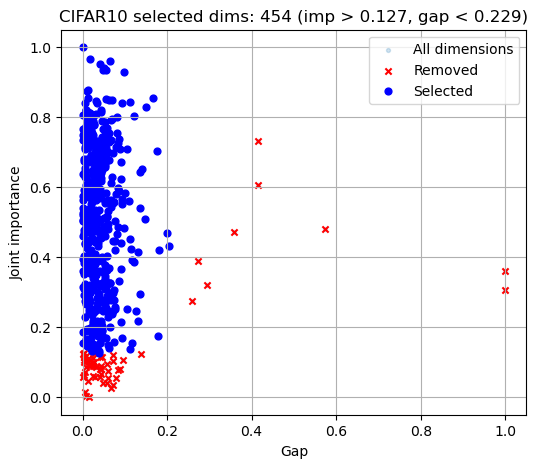

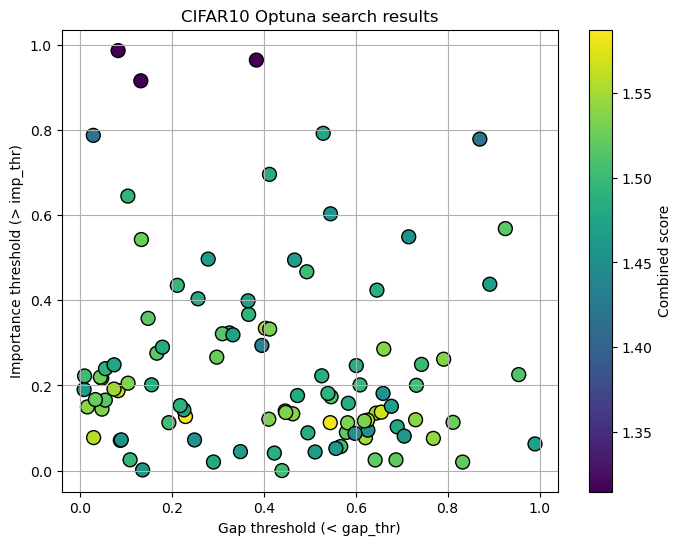

In [48]:

# Scatter plot: selected vs removed dimensions for the best CIFAR10 thresholds
best_idx_cifar10 = _select_dims(
    important_joint_dims,
    gap_dims,
    best_cifar10.params["imp_thr"],
    best_cifar10.params["gap_thr"],
    min_dims=CIFAR_SEARCH_CFG["min_dims"],
)

plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.2, label="All dimensions")

removed_mask = np.ones_like(gap_dims, dtype=bool)
removed_mask[best_idx_cifar10] = False
plt.scatter(gap_dims[removed_mask], important_joint_dims[removed_mask], s=20, color="red", marker="x", label="Removed")
plt.scatter(gap_dims[best_idx_cifar10], important_joint_dims[best_idx_cifar10], s=24, color="blue", marker="o", label="Selected")

plt.title(
    f"CIFAR10 selected dims: {len(best_idx_cifar10)} "
    f"(imp > {best_cifar10.params['imp_thr']:.3f}, gap < {best_cifar10.params['gap_thr']:.3f})"
)
plt.xlabel("Gap")
plt.ylabel("Joint importance")
plt.grid(True)
plt.legend()
plt.show()

def plot_search_results_cifar10(study):
    imp_thrs = [t.params["imp_thr"] for t in study.trials]
    gap_thrs = [t.params["gap_thr"] for t in study.trials]
    scores = [t.value for t in study.trials]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(gap_thrs, imp_thrs, c=scores, cmap="viridis", s=100, edgecolors="k")
    plt.colorbar(scatter, label="Combined score")
    plt.ylabel("Importance threshold (> imp_thr)")
    plt.xlabel("Gap threshold (< gap_thr)")
    plt.title("CIFAR10 Optuna search results")
    plt.grid(True)
    plt.show()

plot_search_results_cifar10(study_cifar10)


Collect CIFAR10 for PCA:  38%|███▊      | 15/40 [00:01<00:02,  8.98it/s]


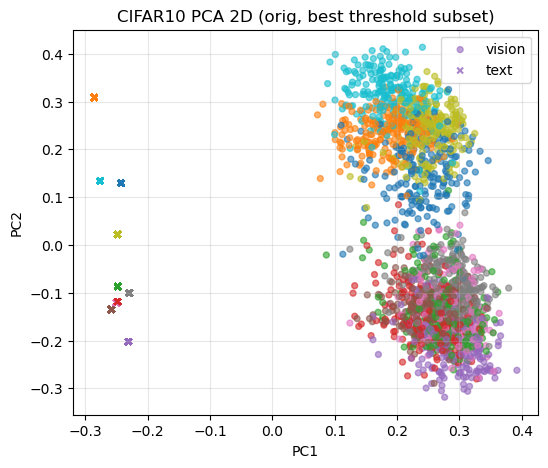

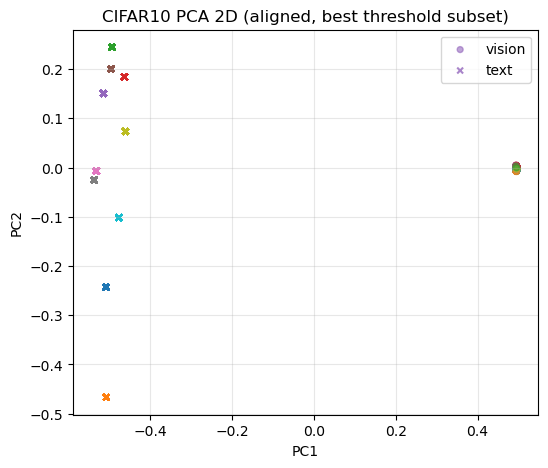

In [49]:

# PCA view for the best threshold selection on CIFAR10
def _collect_latent_for_plot_cifar10(
    loader,
    idx,
    model,
    device="cuda",
    max_samples=4000,
):
    X_buf, Y_buf, Yal_buf, labels_buf = [], [], [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(loader, desc="Collect CIFAR10 for PCA"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)
            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, model, renorm=True)

            Xs = X[:, idx]
            Ys = Y[:, idx]
            Yal_s = Yaln[:, idx]

            b = min(Xs.shape[0], max_samples - seen)
            if b <= 0:
                break
            X_buf.append(Xs[:b].detach().cpu())
            Y_buf.append(Ys[:b].detach().cpu())
            Yal_buf.append(Yal_s[:b].detach().cpu())
            labels_buf.append(labels[:b].detach().cpu())
            seen += b
            if seen >= max_samples:
                break

    X_all = torch.cat(X_buf, dim=0)
    Y_all = torch.cat(Y_buf, dim=0)
    Yal_all = torch.cat(Yal_buf, dim=0)
    labels_all = torch.cat(labels_buf, dim=0).numpy()
    return X_all, Y_all, Yal_all, labels_all

X_all_c, Y_all_c, Yal_all_c, labels_all_c = _collect_latent_for_plot_cifar10(
    test_loader,
    best_idx_cifar10,
    sub_model,
    device=device,
    max_samples=4000,
)

emb_orig_c = torch.cat([X_all_c, Y_all_c], dim=0).numpy()
emb_al_c = torch.cat([X_all_c, Yal_all_c], dim=0).numpy()
labels_2N_c = np.concatenate([labels_all_c, labels_all_c], axis=0)

_plot_pca_2d(
    emb_orig_c,
    labels_2N_c,
    title="CIFAR10 PCA 2D (orig, best threshold subset)",
    max_points=4000,
)

_plot_pca_2d(
    emb_al_c,
    labels_2N_c,
    title="CIFAR10 PCA 2D (aligned, best threshold subset)",
    max_points=4000,
)


## MSCOCO

In [1]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader    
import os
import sys
sys.path.append(os.path.abspath(".."))

from analysis.viz import visualize_3d, tsne_3d
from metrics.retrieval import compute_retrieval
from tqdm import tqdm

import torch.nn.functional as F
import torch 
import torch.nn as nn
import wandb
import copy
from torch.nn.utils import clip_grad_norm_
# Add parent directory to Python path so we can import `models.*`
seed = 123
g = torch.Generator().manual_seed(seed)

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, v_measure_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from dataset.mscoco.mscoco_dataloader_with_labels import mscoco_collate_fn, make_loaders_mscoco
from subspace_alignment.subspace_alignment import fit_subspace_alignment, apply_subspace_alignment, eval_subspace_alignment_mscoco, analyze_subspace_dimensions
device = "cuda:3" if torch.cuda.is_available() else "cpu"

dataset = "mscoco"
precomputed_dir = "/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_train2017_clip"
precomputed_dir_test = "/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_val2017_clip"

/opt/anaconda3/envs/few_dim_modalitygap/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def normalize01(v, eps=1e-12):
    v = v.astype(np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def get_dims_gap(loader, max_samples=20_000, device='cuda'):
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b, _ in tqdm(loader, desc=f"Collecting {max_samples} pairs"):
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()
            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break
    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]

    muX = X.mean(axis=0)  # (D,)
    muY = Y.mean(axis=0)  # (D,)

    gap_dim = np.abs(muX - muY) 
    top_gap = np.argsort(-gap_dim)

    return normalize01(gap_dim), top_gap

In [3]:
train_loader, test_loader = make_loaders_mscoco(
    precomputed_dir=precomputed_dir,
    precomputed_dir_test=precomputed_dir_test,
    batch_size=256
)

[Loaded COCO] 118287 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_train2017_clip | vision_emb shape=(118287, 512)
[Loaded COCO] 5000 samples from /mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_val2017_clip | vision_emb shape=(5000, 512)


### Dims analysis

In [4]:
d_sub = 256
sub_model = fit_subspace_alignment(train_loader,n_fit=10_000, d_sub=d_sub, device=device)
important_dims_txt, important_dims_img, important_joint_dims = analyze_subspace_dimensions(sub_model, device="cuda")
gap_dims, top_gap_idx = get_dims_gap(train_loader)


Collected 10000 samples of dimension 512, these will be used to fit the subspace alignment model with d_sub=256.


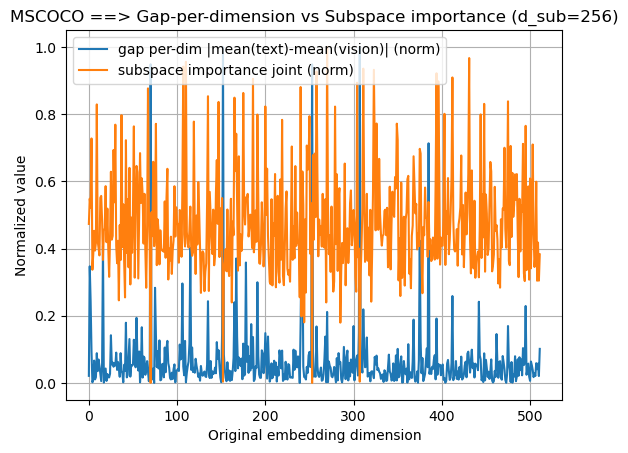

In [5]:
# Plot  plt.figure(figsize=(10, 4))
plt.plot(gap_dims, label="gap per-dim |mean(text)-mean(vision)| (norm)")
plt.plot(important_joint_dims, label="subspace importance joint (norm)")
plt.title(f"MSCOCO ==> Gap-per-dimension vs Subspace importance (d_sub={d_sub})")
plt.xlabel("Original embedding dimension")
plt.ylabel("Normalized value")
plt.grid(True)
plt.legend()
plt.show()

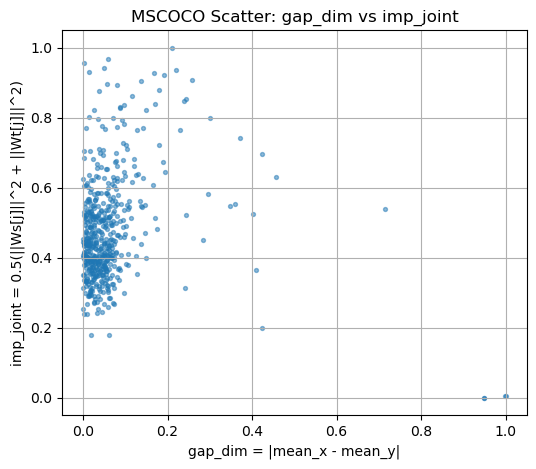

In [6]:
plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.5)
plt.title(f"MSCOCO Scatter: gap_dim vs imp_joint")
plt.xlabel("gap_dim = |mean_x - mean_y|")
plt.ylabel("imp_joint = 0.5(||Ws[j]||^2 + ||Wt[j]||^2)")
plt.grid(True)
plt.show()

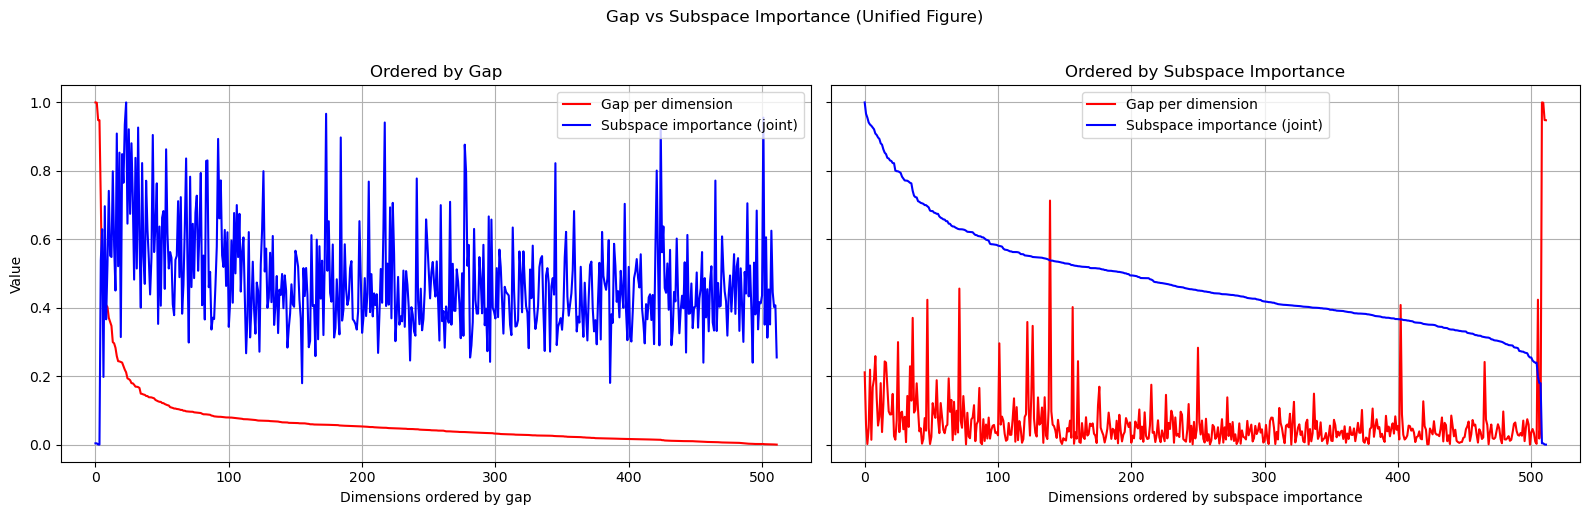

In [7]:
def plot_gap_importance_unified(analysis):
    gap_dim = analysis["gap_dim"]
    imp_joint = analysis["imp_joint"]

    # Orders
    order_gap = np.argsort(-gap_dim)
    order_imp = np.argsort(-imp_joint)

    # Sorted values
    gap_by_gap = gap_dim[order_gap]
    imp_by_gap = imp_joint[order_gap]

    gap_by_imp = gap_dim[order_imp]
    imp_by_imp = imp_joint[order_imp]

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    # Left: ordered by gap
    axes[0].plot(gap_by_gap, label="Gap per dimension", color="red")
    axes[0].plot(imp_by_gap, label="Subspace importance (joint)", color="blue")
    axes[0].set_title("Ordered by Gap")
    axes[0].set_xlabel("Dimensions ordered by gap")
    axes[0].set_ylabel("Value")
    axes[0].grid(True)
    axes[0].legend()

    # Right: ordered by importance
    axes[1].plot(gap_by_imp, label="Gap per dimension", color="red")
    axes[1].plot(imp_by_imp, label="Subspace importance (joint)", color="blue")
    axes[1].set_title("Ordered by Subspace Importance")
    axes[1].set_xlabel("Dimensions ordered by subspace importance")
    axes[1].grid(True)
    axes[1].legend()

    plt.suptitle("Gap vs Subspace Importance (Unified Figure)", y=1.02)
    plt.tight_layout()
    plt.show()


analysis = {
    'gap_dim' : gap_dims,
    'imp_joint' : important_joint_dims
}
plot_gap_importance_unified(analysis)

### Ablation on thresholds selection

In [8]:
import math
try:
    import optuna
except ImportError as exc:
    raise ImportError(
        "optuna is required for Bayesian search. Install with: pip install optuna"
    ) from exc

from analysis.modality_gap import compute_gap
from metrics.clustering import clustering_metrics_two_modalities_multilabel_mscoco

SEARCH_CFG = {
    "n_trials": 100,
    "seed": 0,
    "max_eval_batches": 40,
    "max_cluster_samples": 3000,
    "min_dims": 16,
    "label_mode": "primary",
    "direction": "text_to_vision",
    "n_clusters": 78,
}

In [9]:


def _labels_batch_to_list(labels_batch):
    if torch.is_tensor(labels_batch):
        return [labels_batch[i] for i in range(labels_batch.shape[0])]
    if isinstance(labels_batch, np.ndarray):
        return [labels_batch[i] for i in range(labels_batch.shape[0])]
    if isinstance(labels_batch, (list, tuple)):
        return list(labels_batch)
    return [labels_batch]

def _select_dims(imp, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((imp >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-imp)
        idx = order[:min_dims]
    return np.sort(idx)

def _to_scalar(v):
    if isinstance(v, dict):
        v = v.get("text_vision", next(iter(v.values())))
    if torch.is_tensor(v):
        v = v.item()
    return float(v)

def eval_thresholds(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    device="cuda",
    max_eval_batches=None,
    max_cluster_samples=3000,
    label_mode="primary",
    n_clusters=None,
    direction="text_to_vision",
    min_dims=16,
):
    idx = _select_dims(important_joint_dims, gap_dims, imp_thr, gap_thr, min_dims=min_dims)

    r_orig = {1: [], 5: [], 10: []}
    r_al = {1: [], 5: [], 10: []}
    gaps = ["RMG", "L2M", "L2I", "cosineTP"]
    gaps_orig_batches = {g: [] for g in gaps}
    gaps_al_batches = {g: [] for g in gaps}

    Xt_buf, Xv_buf, Xv_al_buf, y_buf = [], [], [], []
    seen = 0
    n_batches = 0

    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(test_loader, desc="Eval thresholds"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)

            if direction == "text_to_vision":
                X, Y = X, Y
            elif direction == "vision_to_text":
                X, Y = Y, X

            Xs = X[:, idx]
            Ys = Y[:, idx]

            r_orig[1].append(_to_scalar(compute_retrieval("mscoco", (Xs, Ys), top_k=1)))
            r_orig[5].append(_to_scalar(compute_retrieval("mscoco", (Xs, Ys), top_k=5)))
            r_orig[10].append(_to_scalar(compute_retrieval("mscoco", (Xs, Ys), top_k=10)))

            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, sub_model, renorm=True)
            Xal_s = Xn[:, idx]
            Yal_s = Yaln[:, idx]

            r_al[1].append(_to_scalar(compute_retrieval("mscoco", (Xal_s, Yal_s), top_k=1)))
            r_al[5].append(_to_scalar(compute_retrieval("mscoco", (Xal_s, Yal_s), top_k=5)))
            r_al[10].append(_to_scalar(compute_retrieval("mscoco", (Xal_s, Yal_s), top_k=10)))

            for gname in gaps:
                go = compute_gap(gname, Xs, Ys, iterations=None)
                ga = compute_gap(gname, Xal_s, Yal_s, iterations=None)
                gaps_orig_batches[gname].append(_to_scalar(go))
                gaps_al_batches[gname].append(_to_scalar(ga))

            if seen < max_cluster_samples:
                b = min(Xs.shape[0], max_cluster_samples - seen)
                Xt_buf.append(Xs[:b].detach().cpu())
                Xv_buf.append(Ys[:b].detach().cpu())
                Xv_al_buf.append(Yal_s[:b].detach().cpu())
                y_buf.extend(_labels_batch_to_list(labels)[:b])
                seen += b

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    gaps_orig = {g: float(np.mean(v)) for g, v in gaps_orig_batches.items()}
    gaps_al = {g: float(np.mean(v)) for g, v in gaps_al_batches.items()}

    metrics = {
        "n_dims": int(idx.size),
        "dim_idx": idx,
        "retrieval_orig": {k: float(np.mean(v)) for k, v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k, v in r_al.items()},
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_al,
    }

    if len(Xt_buf) > 0:
        Xt_all = torch.cat(Xt_buf, dim=0)
        Xv_all = torch.cat(Xv_buf, dim=0)
        Xv_al_all = torch.cat(Xv_al_buf, dim=0)

        cluster_orig = clustering_metrics_two_modalities_multilabel_mscoco(
            Xt_all, Xv_all, y_buf, n_clusters=n_clusters, random_state=0, label_mode=label_mode
        )
        cluster_al = clustering_metrics_two_modalities_multilabel_mscoco(
            Xt_all, Xv_al_all, y_buf, n_clusters=n_clusters, random_state=0, label_mode=label_mode
        )

        metrics["clustering_orig"] = {
            k: cluster_orig[k]
            for k in ["ARI", "NMI", "Homogeneity", "V-measure", "n_clusters", "n_classes", "label_mode"]
        }
        metrics["clustering_aligned"] = {
            k: cluster_al[k]
            for k in ["ARI", "NMI", "Homogeneity", "V-measure", "n_clusters", "n_classes", "label_mode"]
        }
    else:
        metrics["clustering_orig"] = None
        metrics["clustering_aligned"] = None

    return metrics

def objective(trial):
    imp_thr = trial.suggest_float("imp_thr", 0.0, 1.0)
    gap_thr = trial.suggest_float("gap_thr", 0.0, 1.0)

    metrics = eval_thresholds(
        imp_thr,
        gap_thr,
        test_loader,
        sub_model,
        device=device,
        max_eval_batches=SEARCH_CFG["max_eval_batches"],
        max_cluster_samples=SEARCH_CFG["max_cluster_samples"],
        label_mode=SEARCH_CFG["label_mode"],
        n_clusters=SEARCH_CFG["n_clusters"],
        direction=SEARCH_CFG["direction"],
        min_dims=SEARCH_CFG["min_dims"],
    )

    r_orig = metrics["retrieval_orig"][1]
    r_al = metrics["retrieval_aligned"][1]
    v_orig = metrics["clustering_orig"]["V-measure"] if metrics["clustering_orig"] else 0.0
    v_al = metrics["clustering_aligned"]["V-measure"] if metrics["clustering_aligned"] else 0.0

    score = 0.5 * (r_orig + r_al) + 0.5 * (v_orig + v_al)
    trial.set_user_attr("metrics", metrics)
    trial.set_user_attr("score_terms", {"r_orig": r_orig, "r_al": r_al, "v_orig": v_orig, "v_al": v_al})
    return score

sampler = optuna.samplers.TPESampler(seed=SEARCH_CFG["seed"])
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=SEARCH_CFG["n_trials"])

best = study.best_trial
best_metrics = best.user_attrs["metrics"]

print("Best thresholds:")
print(f"  imp_thr={best.params['imp_thr']:.4f} | gap_thr={best.params['gap_thr']:.4f}")
print(f"  n_dims={best_metrics['n_dims']}")
print("Best metrics (retrieval@1):")
print(f"  orig={best_metrics['retrieval_orig'][1]:.4f} | aligned={best_metrics['retrieval_aligned'][1]:.4f}")
if best_metrics["clustering_orig"]:
    print("Best metrics (V-measure):")
    print(f"  orig={best_metrics['clustering_orig']['V-measure']:.4f} | aligned={best_metrics['clustering_aligned']['V-measure']:.4f}")
print("Best gaps (orig):", best_metrics["gaps_orig"])

print("Best gaps (aligned):", best_metrics["gaps_aligned"])

# Optional: inspect top trials
top = sorted(study.trials, key=lambda t: t.value, reverse=True)[:5]
for i, t in enumerate(top, 1):
    m = t.user_attrs["metrics"]
    print(
        f"Top {i}: score={t.value:.4f} imp={t.params['imp_thr']:.3f} gap={t.params['gap_thr']:.3f} "
        f"dims={m['n_dims']} r1_o={m['retrieval_orig'][1]:.4f} r1_a={m['retrieval_aligned'][1]:.4f} "
        f"v_o={m['clustering_orig']['V-measure'] if m['clustering_orig'] else 0.0:.4f} "
        f"v_a={m['clustering_aligned']['V-measure'] if m['clustering_aligned'] else 0.0:.4f}"
    )

[I 2026-03-11 11:46:39,576] A new study created in memory with name: no-name-cdad387d-8826-4065-9ac8-44bf5410e686
Eval thresholds: 100%|██████████| 20/20 [00:00<00:00, 84.98it/s]
[I 2026-03-11 11:46:40,223] Trial 0 finished with value: 0.9646714767769995 and parameters: {'imp_thr': 0.5488135039273248, 'gap_thr': 0.7151893663724195}. Best is trial 0 with value: 0.9646714767769995.
Eval thresholds: 100%|██████████| 20/20 [00:00<00:00, 187.98it/s]
[I 2026-03-11 11:46:40,540] Trial 1 finished with value: 0.8884471792515366 and parameters: {'imp_thr': 0.6027633760716439, 'gap_thr': 0.5448831829968969}. Best is trial 0 with value: 0.9646714767769995.
Eval thresholds: 100%|██████████| 20/20 [00:00<00:00, 127.66it/s]
[I 2026-03-11 11:46:41,131] Trial 2 finished with value: 1.1127324283615567 and parameters: {'imp_thr': 0.4236547993389047, 'gap_thr': 0.6458941130666561}. Best is trial 2 with value: 1.1127324283615567.
Eval thresholds: 100%|██████████| 20/20 [00:00<00:00, 134.23it/s]
[I 2026-03-

Best thresholds:
  imp_thr=0.1868 | gap_thr=0.9663
  n_dims=506
Best metrics (retrieval@1):
  orig=0.7530 | aligned=0.7370
Best metrics (V-measure):
  orig=0.3914 | aligned=0.4397
Best gaps (orig): {'RMG': 0.7687628933994344, 'L2M': 0.5352290153503418, 'L2I': 1.0476354777812957, 'cosineTP': 0.3210568979382515}
Best gaps (aligned): {'RMG': 0.6866272372031168, 'L2M': 0.07778531014919281, 'L2I': 0.8125970840454102, 'cosineTP': 0.5805701166391373}
Top 1: score=1.1606 imp=0.187 gap=0.966 dims=506 r1_o=0.7530 r1_a=0.7370 v_o=0.3914 v_a=0.4397
Top 2: score=1.1606 imp=0.193 gap=0.881 dims=506 r1_o=0.7530 r1_a=0.7370 v_o=0.3914 v_a=0.4397
Top 3: score=1.1606 imp=0.185 gap=0.830 dims=506 r1_o=0.7530 r1_a=0.7370 v_o=0.3914 v_a=0.4397
Top 4: score=1.1606 imp=0.191 gap=0.907 dims=506 r1_o=0.7530 r1_a=0.7370 v_o=0.3914 v_a=0.4397
Top 5: score=1.1606 imp=0.196 gap=0.923 dims=506 r1_o=0.7530 r1_a=0.7370 v_o=0.3914 v_a=0.4397


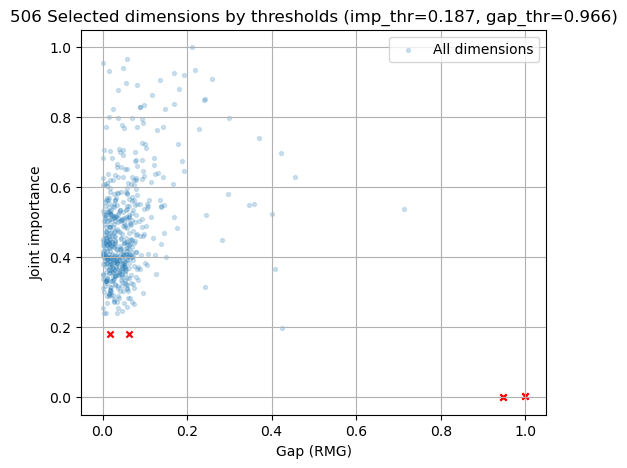

In [10]:
# Create 2d plot y axis joint importance, x axes gap. All the dimensions are red x, excluding the ones selected by the best thresholds, which are blue circles. 
gap_dim = best_metrics["gaps_orig"]["RMG"]
imp_joint = important_joint_dims
imp_thr = best.params["imp_thr"]
gap_thr = best.params["gap_thr"]    
filter_mask = (important_joint_dims >= imp_thr) & (gap_dims <= gap_thr)
filtered_gap_dim = gap_dims[filter_mask]
filtered_imp_joint = important_joint_dims[filter_mask]

plt.figure(figsize=(6, 5))
plt.scatter(analysis["gap_dim"], analysis["imp_joint"], s=8, alpha=0.2, label="All dimensions")

selected_idx = _select_dims(important_joint_dims, gap_dims, imp_thr, gap_thr, min_dims=SEARCH_CFG["min_dims"])
# x red marker on not selected dimensions
for i in range(len(gap_dims)):
    if i in selected_idx:
        continue
    else:
        plt.scatter(gap_dims[i], important_joint_dims[i], s=20, color="red", marker="x", )

plt.title(f"{len(selected_idx)} Selected dimensions by thresholds (imp_thr={imp_thr:.3f}, gap_thr={gap_thr:.3f})")
plt.xlabel("Gap (RMG)")
plt.ylabel("Joint importance")
plt.grid(True)
plt.legend()
plt.show()  


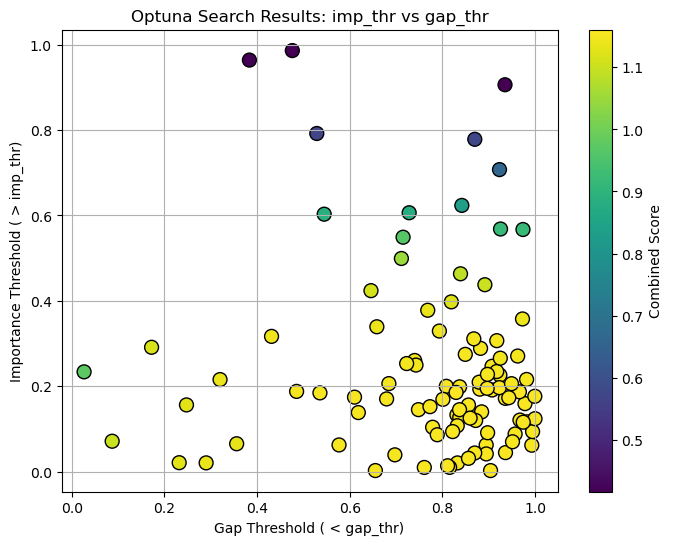

In [11]:
# Create the 2d plot of the search results with x red on the removed dims
def plot_search_results(study):
    imp_thrs = [t.params["imp_thr"] for t in study.trials]
    gap_thrs = [t.params["gap_thr"] for t in study.trials]
    scores = [t.value for t in study.trials]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(gap_thrs, imp_thrs, c=scores, cmap="viridis", s=100, edgecolors="k")
    plt.colorbar(scatter, label="Combined Score")
    plt.ylabel("Importance Threshold ( > imp_thr)")
    plt.xlabel("Gap Threshold ( < gap_thr)")
    plt.title("Optuna Search Results: imp_thr vs gap_thr")
    plt.grid(True)
    plt.show()

plot_search_results(study)

Collect for PCA:  75%|███████▌  | 15/20 [00:00<00:00, 327.01it/s]


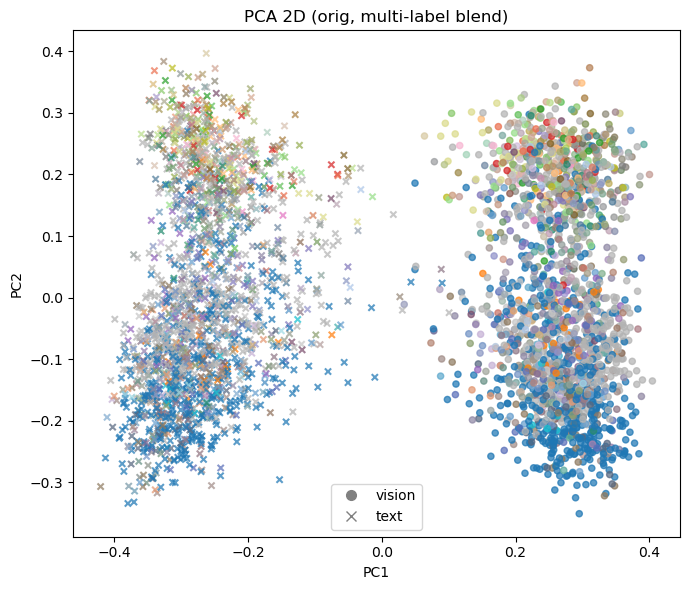

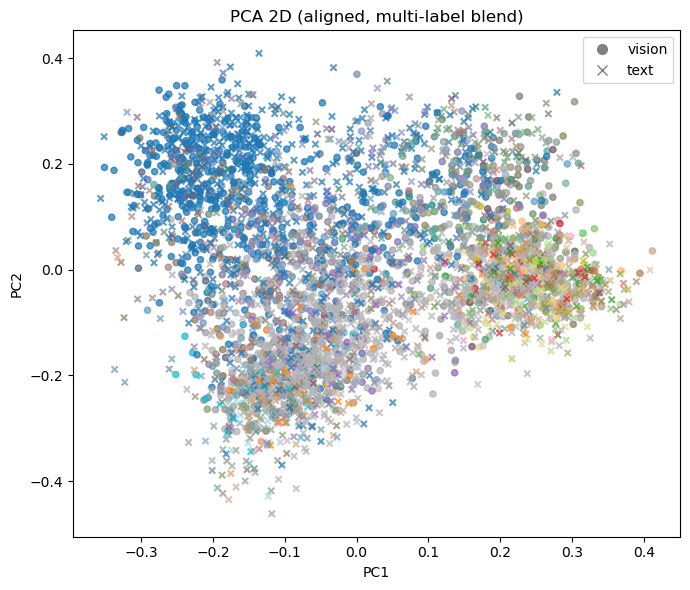

In [12]:
# Latent space visualization with multi-label blend
from analysis.viz import plot_pca_2d_mscoco_multilabel_blend

def _collect_latent_for_plot(
    loader,
    idx,
    model,
    device="cuda",
    max_samples=4000,
    direction="text_to_vision",
    ):
    X_buf, Y_buf, Yal_buf = [], [], []
    labels_all = []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(loader, desc="Collect for PCA"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)

            if direction == "text_to_vision":
                X, Y = X, Y
            elif direction == "vision_to_text":
                X, Y = Y, X

            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, model, renorm=True)
            Xs = X[:, idx]
            Ys = Y[:, idx]
            Yal_s = Yaln[:, idx]

            b = min(Xs.shape[0], max_samples - seen)
            if b <= 0:
                break
            X_buf.append(Xs[:b].detach().cpu())
            Y_buf.append(Ys[:b].detach().cpu())
            Yal_buf.append(Yal_s[:b].detach().cpu())
            labels_all.extend(_labels_batch_to_list(labels)[:b])
            seen += b
            if seen >= max_samples:
                break
    X_all = torch.cat(X_buf, dim=0)
    Y_all = torch.cat(Y_buf, dim=0)
    Yal_all = torch.cat(Yal_buf, dim=0)
    return X_all, Y_all, Yal_all, labels_all

best_idx = _select_dims(
    important_joint_dims,
    gap_dims,
    best.params["imp_thr"],
    best.params["gap_thr"],
    min_dims=SEARCH_CFG["min_dims"],
)

X_all, Y_all, Yal_all, labels_all = _collect_latent_for_plot(
    test_loader,
    best_idx,
    sub_model,
    device=device,
    max_samples=4000,
    direction=SEARCH_CFG["direction"],
 )

emb_orig = torch.cat([X_all, Y_all], dim=0).numpy()
emb_al = torch.cat([X_all, Yal_all], dim=0).numpy()

plot_pca_2d_mscoco_multilabel_blend(
    emb_2N=emb_orig,
    labels_per_sample=labels_all,
    title="PCA 2D (orig, multi-label blend)",
    max_points=4000,
    max_classes_to_color=20,
 )

plot_pca_2d_mscoco_multilabel_blend(
    emb_2N=emb_al,
    labels_per_sample=labels_all,
    title="PCA 2D (aligned, multi-label blend)",
    max_points=4000,
    max_classes_to_color=20,
 )

## Flickr30K

### Constants

In [37]:

import sys
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

sys.path.append(os.path.abspath(".."))

from subspace_alignment.subspace_alignment import (
    fit_subspace_alignment,
    apply_subspace_alignment,
    analyze_subspace_dimensions,
)

from dataset.flickr30k.dataloader_embeddings_with_labels import EmbeddingsDatasetWithLabels
from dataset.flickr30k.flickr_imagenet_utils import original_idx2class
from metrics.retrieval import retrieval
from analysis.modality_gap import compute_gap
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    v_measure_score,
)

seed = 123
g = torch.Generator().manual_seed(seed)


In [ ]:
# Define constants
dataset = "flickr30k"
precomputed_dir = "/mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/clip_vit_b_32___laion2b_s34b_b79k"
device = "cuda:3" if torch.cuda.is_available() else "cpu"

In [25]:

def normalize01(v, eps=1e-12):
    v = v.astype(np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def get_dims_gap(loader, max_samples=20_000, device="cuda"):
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b, _ in tqdm(loader, desc=f"Collecting {max_samples} pairs"):
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()
            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break

    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]

    muX = X.mean(axis=0)
    muY = Y.mean(axis=0)

    gap_dim = np.abs(muX - muY)
    top_gap = np.argsort(-gap_dim)
    return normalize01(gap_dim), top_gap

Collected 10000 samples of dimension 512, these will be used to fit the subspace alignment model with d_sub=256.


In [27]:
# Let's get the data
precomputed_dir = "/mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/clip_vit_b_32___laion2b_s34b_b79k"
dataset = EmbeddingsDatasetWithLabels(precomputed_dir=precomputed_dir, split_name="flickr30k")

[Loaded] 31783 samples from /mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/clip_vit_b_32___laion2b_s34b_b79k


### Filter out data construct dataloaders
We need to filter out the classes with very few samples, this may make the classifier struggle.

Analyzing label distribution: 100%|██████████| 31783/31783 [00:00<00:00, 194465.65it/s]


Unique labels: 815
Total samples: 31783


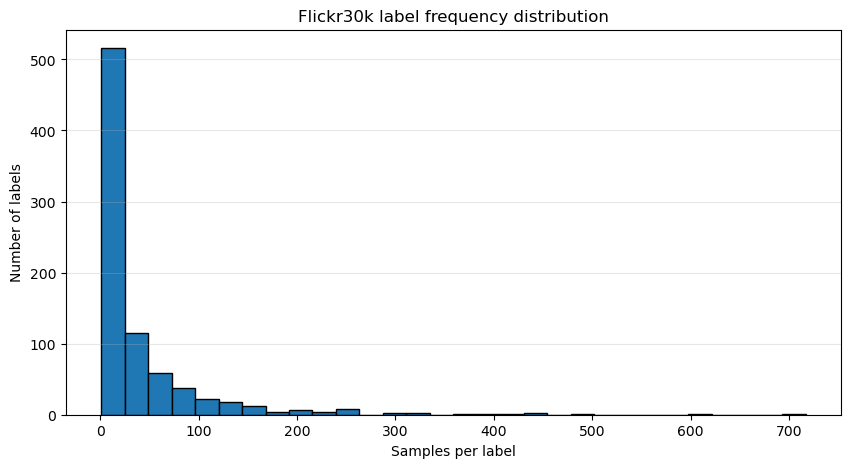

In [31]:
### Given the train_loader and the test_loader, discover how many unique labels are in the dataset, and how many samples per label. Plot the distribution of samples per label as a histogram.
def analyze_label_distribution(loader):
    label_counts = {}

    for batch in tqdm(loader, desc="Analyzing label distribution"):
        # Works for both Dataset samples and DataLoader batches
        if isinstance(batch, (list, tuple)) and len(batch) == 3:
            _, _, labels = batch
        else:
            continue

        if torch.is_tensor(labels):
            if labels.ndim == 0:  # single sample label (Dataset iteration)
                labels_iter = [int(labels.item())]
            else:  # batched labels (DataLoader iteration)
                labels_iter = labels.detach().cpu().view(-1).tolist()
        elif isinstance(labels, (list, tuple, np.ndarray)):
            labels_iter = np.asarray(labels).reshape(-1).tolist()
        else:
            labels_iter = [int(labels)]

        for lab in labels_iter:
            label_counts[lab] = label_counts.get(lab, 0) + 1

    return label_counts

label_counts = analyze_label_distribution(dataset)
print(f"Unique labels: {len(label_counts)}")
print(f"Total samples: {sum(label_counts.values())}")

# Histogram: distribution of "samples per label"
counts = list(label_counts.values())
plt.figure(figsize=(10, 5))
plt.hist(counts, bins=30, edgecolor="black")
plt.xlabel("Samples per label")
plt.ylabel("Number of labels")
plt.title("Flickr30k label frequency distribution")
plt.grid(axis="y", alpha=0.3)
plt.show()



In [32]:
# We should make sure to filter out classes that have too few samples, otherwise the classifier will struggle to learn. 
# Let's set a threshold of 1% of dataset total length as samples per class constraint.
# threshold = int(0.01 * len(dataset))
threshold = 10
print(f"Filtering out classes with less than {threshold} samples...")
class_counts = {}
for _, _, label in dataset:
    if label.item() not in class_counts:
        class_counts[label.item()] = 0
    class_counts[label.item()] += 1
    
filtered_classes = {cls for cls, count in class_counts.items() if count >= threshold}
print(f"Number of classes after filtering: {len(filtered_classes)}")
filtered_indices = [i for i, (_,_, label) in enumerate(dataset) if label.item() in filtered_classes]
filtered_dataset = torch.utils.data.Subset(dataset, filtered_indices)
print(f"Number of samples after filtering: {len(filtered_dataset)}")

Filtering out classes with less than 10 samples...
Number of classes after filtering: 465
Number of samples after filtering: 30471


In [33]:
# sort the class count by count value
class_counts = {cls: count for cls, count in class_counts.items() if cls in filtered_classes}
class_counts = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True))
# print("Class counts after filtering:")
# for cls, count in class_counts.items():
#     print(f"Class {cls}: {count} samples")  

In [34]:
# Now split the filtered dataset into train and test only (stratified).
# We'll use a 80-20 split for train and test.

from sklearn.model_selection import train_test_split

# Extract labels for the filtered dataset
filtered_labels = []
for i in filtered_indices:
    _, _, label = dataset[i]
    filtered_labels.append(label.item())

filtered_labels = np.array(filtered_labels)

# Indices relative to filtered_dataset
all_indices = np.arange(len(filtered_dataset))

# Stratified split: Train (80%) and Test (20%)
train_idx, test_idx, _, _ = train_test_split(
    all_indices,
    filtered_labels,
    test_size=0.20,
    stratify=filtered_labels,
    random_state=seed
)

# Create final subsets
train_dataset = torch.utils.data.Subset(filtered_dataset, train_idx)
test_dataset = torch.utils.data.Subset(filtered_dataset, test_idx)

print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")


Train size: 24376
Test size: 6095


In [42]:
# check the class distribution in each split
def get_class_distribution(subset):
    class_counts = {}
    for _, _, label in subset:
        if label.item() not in class_counts:
            class_counts[label.item()] = 0
        class_counts[label.item()] += 1
    return class_counts

train_class_dist = get_class_distribution(train_dataset)
test_class_dist = get_class_distribution(test_dataset)

print("Number of classes in train set:", len(train_class_dist))
print("Number of classes in test set:", len(test_class_dist))
assert set(train_class_dist.keys()) == set(test_class_dist.keys()) and len(train_class_dist) == len(test_class_dist), "Train and test sets have different classes after filtering!"   
    

Number of classes in train set: 465
Number of classes in test set: 465


In [38]:
len_classes = len(train_class_dist)

# build a mapping from the original class indices to the new class indices after filtering
filtered_idx2class = {idx: val for idx, val in enumerate(sorted(train_class_dist.keys()))}
filtered_class2idx = {v: k for k, v in filtered_idx2class.items()}
new_idx2class = {idx: original_idx2class[val] for idx, val in filtered_idx2class.items()}
new_class2idx = {v: k for k, v in new_idx2class.items()}


In [39]:
# Now we can build the dataloaders for each split.
bs = 2048
train_dataloader = DataLoader(train_dataset, batch_size=bs, shuffle=True, generator=g)
test_dataloader = DataLoader(test_dataset, batch_size=bs, shuffle=False, generator=g)

### Ablation on threshold selection

Bayesian search for Flickr30k using the same subspace-alignment analysis already used for MSCOCO and CIFAR10, with `d_sub=256`.

In [43]:
d_sub = 256
sub_model = fit_subspace_alignment(train_loader, n_fit=10_000, d_sub=d_sub, device=device)
important_dims_txt, important_dims_img, important_joint_dims = analyze_subspace_dimensions(sub_model, device=device)
gap_dims, top_gap_idx = get_dims_gap(train_dataloader, max_samples=20_000, device=device)
n_clusters = len(train_class_dist)

Collected 10000 samples of dimension 512, these will be used to fit the subspace alignment model with d_sub=256.


In [44]:

import math
try:
    import optuna
except ImportError as exc:
    raise ImportError(
        "optuna is required for Bayesian search. Install with: pip install optuna"
    ) from exc

FLICKR_SEARCH_CFG = {
    "n_trials": 100,
    "seed": 0,
    "max_eval_batches": 40,
    "max_cluster_samples": 3000,
    "min_dims": 16,
    "direction": "text_to_vision",
    "n_clusters": n_clusters,
}

def _select_dims(imp, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((imp >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-imp)
        idx = order[:min_dims]
    return np.sort(idx)

def _to_scalar(v):
    if isinstance(v, dict):
        v = v.get("text_vision", next(iter(v.values())))
    if torch.is_tensor(v):
        v = v.item()
    return float(v)

def retrieval_flickr30k(X, Y, top_k=1):
    X_np = X.detach().cpu().numpy() if torch.is_tensor(X) else np.asarray(X)
    Y_np = Y.detach().cpu().numpy() if torch.is_tensor(Y) else np.asarray(Y)
    return float(retrieval(X_np, Y_np, top_k=top_k))

def _clustering_metrics_two_modalities_flickr30k(X, Y, labels, n_clusters=None, random_state=0):
    '''
    KMeans on [X; Y] and clustering metrics against duplicated Flickr30k labels.
    If n_clusters is None, infer it from the labels in the collected subset.
    '''
    X_np = X.detach().cpu().numpy()
    Y_np = Y.detach().cpu().numpy()

    if torch.is_tensor(labels):
        L_np = labels.detach().cpu().numpy()
    else:
        L_np = np.asarray(labels)

    L_np = np.asarray(L_np).reshape(-1)
    emb = np.vstack([X_np, Y_np])
    true2 = np.concatenate([L_np, L_np], axis=0)

    if n_clusters is None:
        n_clusters = int(np.unique(L_np).size)

    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    pred = km.fit_predict(emb)

    return {
        "ARI": adjusted_rand_score(true2, pred),
        "NMI": normalized_mutual_info_score(true2, pred),
        "Homogeneity": homogeneity_score(true2, pred),
        "V-measure": v_measure_score(true2, pred),
        "cluster_labels": pred,
        "true_labels_2N": true2,
        "emb_2N": emb,
        "n_clusters": n_clusters,
    }

def _plot_pca_2d(emb_2N, labels_2N, title, max_points=6000):
    n2 = emb_2N.shape[0]
    n = n2 // 2
    modality = np.concatenate([
        np.zeros(n, dtype=np.int32),
        np.ones(n2 - n, dtype=np.int32),
    ])

    if n2 > max_points:
        idx = np.random.RandomState(0).choice(n2, size=max_points, replace=False)
        emb_2N = emb_2N[idx]
        labels_2N = labels_2N[idx]
        modality = modality[idx]

    z = PCA(n_components=2, random_state=0).fit_transform(emb_2N)

    plt.figure(figsize=(6, 5))
    sc_vis = plt.scatter(
        z[modality == 1, 0], z[modality == 1, 1],
        c=labels_2N[modality == 1], s=20, marker="o", alpha=0.7, label="vision"
    )
    plt.scatter(
        z[modality == 0, 0], z[modality == 0, 1],
        c=labels_2N[modality == 0], s=20, marker="x", alpha=0.8,
        cmap=sc_vis.cmap, norm=sc_vis.norm, label="text"
    )
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.colorbar(sc_vis, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def eval_thresholds_flickr30k(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    device="cuda",
    max_eval_batches=None,
    max_cluster_samples=3000,
    n_clusters=None,
    direction="text_to_vision",
    min_dims=16,
):
    idx = _select_dims(important_joint_dims, gap_dims, imp_thr, gap_thr, min_dims=min_dims)

    r_orig = {1: [], 5: [], 10: []}
    r_al = {1: [], 5: [], 10: []}
    gaps = ["RMG", "L2M", "L2I", "cosineTP"]
    gaps_orig_batches = {g: [] for g in gaps}
    gaps_al_batches = {g: [] for g in gaps}

    Xt_buf, Xv_buf, Xt_al_buf, Xv_al_buf, y_buf = [], [], [], [], []
    seen = 0
    n_batches = 0

    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(test_loader, desc="Eval thresholds Flickr30k"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)
            labels = labels.to(device)

            Xs = X[:, idx]
            Ys = Y[:, idx]

            if direction == "text_to_vision":
                q_orig, t_orig = Xs, Ys
            else:
                q_orig, t_orig = Ys, Xs

            r_orig[1].append(retrieval_flickr30k(q_orig, t_orig, top_k=1))
            r_orig[5].append(retrieval_flickr30k(q_orig, t_orig, top_k=5))
            r_orig[10].append(retrieval_flickr30k(q_orig, t_orig, top_k=10))

            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, sub_model, renorm=True)
            Xal_s = Xn[:, idx]
            Yal_s = Yaln[:, idx]

            if direction == "text_to_vision":
                q_al, t_al = Xal_s, Yal_s
            else:
                q_al, t_al = Yal_s, Xal_s

            r_al[1].append(retrieval_flickr30k(q_al, t_al, top_k=1))
            r_al[5].append(retrieval_flickr30k(q_al, t_al, top_k=5))
            r_al[10].append(retrieval_flickr30k(q_al, t_al, top_k=10))

            for gname in gaps:
                go = compute_gap(gname, Xs, Ys, iterations=None)
                ga = compute_gap(gname, Xal_s, Yal_s, iterations=None)
                gaps_orig_batches[gname].append(_to_scalar(go))
                gaps_al_batches[gname].append(_to_scalar(ga))

            if seen < max_cluster_samples:
                b = min(Xs.shape[0], max_cluster_samples - seen)
                Xt_buf.append(Xs[:b].detach().cpu())
                Xv_buf.append(Ys[:b].detach().cpu())
                Xt_al_buf.append(Xal_s[:b].detach().cpu())
                Xv_al_buf.append(Yal_s[:b].detach().cpu())
                y_buf.append(labels[:b].detach().cpu())
                seen += b

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    gaps_orig = {g: float(np.mean(v)) for g, v in gaps_orig_batches.items()}
    gaps_al = {g: float(np.mean(v)) for g, v in gaps_al_batches.items()}

    metrics = {
        "n_dims": int(idx.size),
        "dim_idx": idx,
        "retrieval_orig": {k: float(np.mean(v)) for k, v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k, v in r_al.items()},
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_al,
    }

    if len(Xt_buf) > 0:
        Xt_all = torch.cat(Xt_buf, dim=0)
        Xv_all = torch.cat(Xv_buf, dim=0)
        Xt_al_all = torch.cat(Xt_al_buf, dim=0)
        Xv_al_all = torch.cat(Xv_al_buf, dim=0)
        y_all = torch.cat(y_buf, dim=0)

        if direction == "text_to_vision":
            cluster_orig = _clustering_metrics_two_modalities_flickr30k(
                Xt_all, Xv_all, y_all, n_clusters=n_clusters, random_state=0
            )
            cluster_al = _clustering_metrics_two_modalities_flickr30k(
                Xt_al_all, Xv_al_all, y_all, n_clusters=n_clusters, random_state=0
            )
        else:
            cluster_orig = _clustering_metrics_two_modalities_flickr30k(
                Xv_all, Xt_all, y_all, n_clusters=n_clusters, random_state=0
            )
            cluster_al = _clustering_metrics_two_modalities_flickr30k(
                Xv_al_all, Xt_al_all, y_all, n_clusters=n_clusters, random_state=0
            )

        metrics["clustering_orig"] = {
            k: cluster_orig[k] for k in ["ARI", "NMI", "Homogeneity", "V-measure", "n_clusters"]
        }
        metrics["clustering_aligned"] = {
            k: cluster_al[k] for k in ["ARI", "NMI", "Homogeneity", "V-measure", "n_clusters"]
        }
    else:
        metrics["clustering_orig"] = None
        metrics["clustering_aligned"] = None

    return metrics

def objective_flickr30k(trial):
    imp_thr = trial.suggest_float("imp_thr", 0.0, 1.0)
    gap_thr = trial.suggest_float("gap_thr", 0.0, 1.0)

    metrics = eval_thresholds_flickr30k(
        imp_thr,
        gap_thr,
        test_loader,
        sub_model,
        device=device,
        max_eval_batches=FLICKR_SEARCH_CFG["max_eval_batches"],
        max_cluster_samples=FLICKR_SEARCH_CFG["max_cluster_samples"],
        n_clusters=FLICKR_SEARCH_CFG["n_clusters"],
        direction=FLICKR_SEARCH_CFG["direction"],
        min_dims=FLICKR_SEARCH_CFG["min_dims"],
    )

    r_orig = metrics["retrieval_orig"][1]
    r_al = metrics["retrieval_aligned"][1]
    v_orig = metrics["clustering_orig"]["V-measure"] if metrics["clustering_orig"] else 0.0
    v_al = metrics["clustering_aligned"]["V-measure"] if metrics["clustering_aligned"] else 0.0

    score = 0.5 * (r_orig + r_al) + 0.5 * (v_orig + v_al)
    trial.set_user_attr("metrics", metrics)
    trial.set_user_attr(
        "score_terms",
        {"r_orig": r_orig, "r_al": r_al, "v_orig": v_orig, "v_al": v_al},
    )
    return score

sampler = optuna.samplers.TPESampler(seed=FLICKR_SEARCH_CFG["seed"])
study_flickr30k = optuna.create_study(direction="maximize", sampler=sampler)
study_flickr30k.optimize(objective_flickr30k, n_trials=FLICKR_SEARCH_CFG["n_trials"])

best_flickr30k = study_flickr30k.best_trial
best_metrics_flickr30k = best_flickr30k.user_attrs["metrics"]

print("Best thresholds (Flickr30k):")
print(f"  imp_thr={best_flickr30k.params['imp_thr']:.4f} | gap_thr={best_flickr30k.params['gap_thr']:.4f}")
print(f"  n_dims={best_metrics_flickr30k['n_dims']}")
print("Best metrics (retrieval@1):")
print(f"  orig={best_metrics_flickr30k['retrieval_orig'][1]:.4f} | aligned={best_metrics_flickr30k['retrieval_aligned'][1]:.4f}")
if best_metrics_flickr30k["clustering_orig"]:
    print("Best metrics (V-measure):")
    print(
        f"  orig={best_metrics_flickr30k['clustering_orig']['V-measure']:.4f} | "
        f"aligned={best_metrics_flickr30k['clustering_aligned']['V-measure']:.4f}"
    )
    print(f"  inferred clusters={best_metrics_flickr30k['clustering_orig']['n_clusters']}")
print("Best gaps (orig):", best_metrics_flickr30k["gaps_orig"])
print("Best gaps (aligned):", best_metrics_flickr30k["gaps_aligned"])

top_flickr30k = sorted(study_flickr30k.trials, key=lambda t: t.value, reverse=True)[:5]
for i, t in enumerate(top_flickr30k, 1):
    m = t.user_attrs["metrics"]
    print(
        f"Top {i}: score={t.value:.4f} imp={t.params['imp_thr']:.3f} gap={t.params['gap_thr']:.3f} "
        f"dims={m['n_dims']} r1_o={m['retrieval_orig'][1]:.4f} r1_a={m['retrieval_aligned'][1]:.4f} "
        f"v_o={m['clustering_orig']['V-measure'] if m['clustering_orig'] else 0.0:.4f} "
        f"v_a={m['clustering_aligned']['V-measure'] if m['clustering_aligned'] else 0.0:.4f}"
    )


[I 2026-03-11 07:43:55,190] A new study created in memory with name: no-name-57e3669e-03e9-4b31-b6a5-962d79a4d261
Eval thresholds Flickr30k:   0%|          | 0/25 [00:00<?, ?it/s]

Eval thresholds Flickr30k: 100%|██████████| 25/25 [00:00<00:00, 92.94it/s]
[I 2026-03-11 07:43:57,001] Trial 0 finished with value: 1.3151183917702687 and parameters: {'imp_thr': 0.5488135039273248, 'gap_thr': 0.7151893663724195}. Best is trial 0 with value: 1.3151183917702687.
Eval thresholds Flickr30k: 100%|██████████| 25/25 [00:00<00:00, 127.72it/s]
[I 2026-03-11 07:43:58,210] Trial 1 finished with value: 1.2053333661834413 and parameters: {'imp_thr': 0.6027633760716439, 'gap_thr': 0.5448831829968969}. Best is trial 0 with value: 1.3151183917702687.
Eval thresholds Flickr30k: 100%|██████████| 25/25 [00:00<00:00, 94.84it/s]
[I 2026-03-11 07:44:01,126] Trial 2 finished with value: 1.4536970454882132 and parameters: {'imp_thr': 0.4236547993389047, 'gap_thr': 0.6458941130666561}. Best is trial 2 with value: 1.4536970454882132.
Eval thresholds Flickr30k: 100%|██████████| 25/25 [00:00<00:00, 96.56it/s]
[I 2026-03-11 07:44:03,975] Trial 3 finished with value: 1.4455819377742394 and paramet

Best thresholds (Flickr30k):
  imp_thr=0.3045 | gap_thr=0.6595
  n_dims=487
Best metrics (retrieval@1):
  orig=0.8735 | aligned=0.8648
Best metrics (V-measure):
  orig=0.6045 | aligned=0.6273
  inferred clusters=465
Best gaps (orig): {'RMG': 0.772621406408623, 'L2M': 0.5373623466491699, 'L2I': 1.0530427503585815, 'cosineTP': 0.3445663583278656}
Best gaps (aligned): {'RMG': 0.6971657905187559, 'L2M': 0.09047549843788147, 'L2I': 0.8455776762962341, 'cosineTP': 0.5847514390945434}
Top 1: score=1.4850 imp=0.304 gap=0.660 dims=487 r1_o=0.8735 r1_a=0.8648 v_o=0.6045 v_a=0.6273
Top 2: score=1.4850 imp=0.288 gap=0.865 dims=496 r1_o=0.8744 r1_a=0.8658 v_o=0.6049 v_a=0.6248
Top 3: score=1.4849 imp=0.260 gap=0.740 dims=503 r1_o=0.8743 r1_a=0.8660 v_o=0.6008 v_a=0.6288
Top 4: score=1.4849 imp=0.258 gap=0.722 dims=503 r1_o=0.8743 r1_a=0.8660 v_o=0.6008 v_a=0.6288
Top 5: score=1.4849 imp=0.258 gap=0.803 dims=503 r1_o=0.8743 r1_a=0.8660 v_o=0.6008 v_a=0.6288


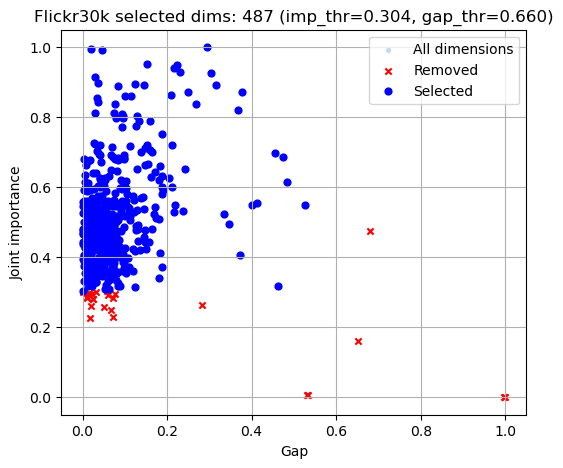

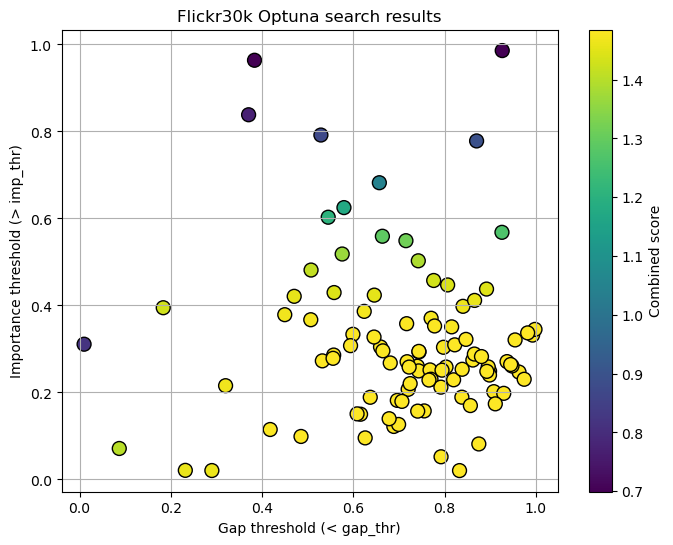

In [47]:

# Scatter plot: selected vs removed dimensions for the best Flickr30k thresholds
best_idx_flickr30k = _select_dims(
    important_joint_dims,
    gap_dims,
    best_flickr30k.params["imp_thr"],
    best_flickr30k.params["gap_thr"],
    min_dims=FLICKR_SEARCH_CFG["min_dims"],
)

plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.2, label="All dimensions")

removed_mask = np.ones_like(gap_dims, dtype=bool)
removed_mask[best_idx_flickr30k] = False
plt.scatter(gap_dims[removed_mask], important_joint_dims[removed_mask], s=20, color="red", marker="x", label="Removed")
plt.scatter(gap_dims[best_idx_flickr30k], important_joint_dims[best_idx_flickr30k], s=24, color="blue", marker="o", label="Selected")

plt.title(
    f"Flickr30k selected dims: {len(best_idx_flickr30k)} "
    f"(imp_thr={best_flickr30k.params['imp_thr']:.3f}, gap_thr={best_flickr30k.params['gap_thr']:.3f})"
)
plt.xlabel("Gap")
plt.ylabel("Joint importance")
plt.grid(True)
plt.legend()
plt.show()

def plot_search_results_flickr30k(study):
    imp_thrs = [t.params["imp_thr"] for t in study.trials]
    gap_thrs = [t.params["gap_thr"] for t in study.trials]
    scores = [t.value for t in study.trials]

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(gap_thrs, imp_thrs, c=scores, cmap="viridis", s=100, edgecolors="k")
    plt.colorbar(scatter, label="Combined score")
    plt.ylabel("Importance threshold (> imp_thr)")
    plt.xlabel("Gap threshold (< gap_thr)")
    plt.title("Flickr30k Optuna search results")
    plt.grid(True)
    plt.show()

plot_search_results_flickr30k(study_flickr30k)


Collect Flickr30k for PCA:  60%|██████    | 15/25 [00:00<00:00, 203.28it/s]


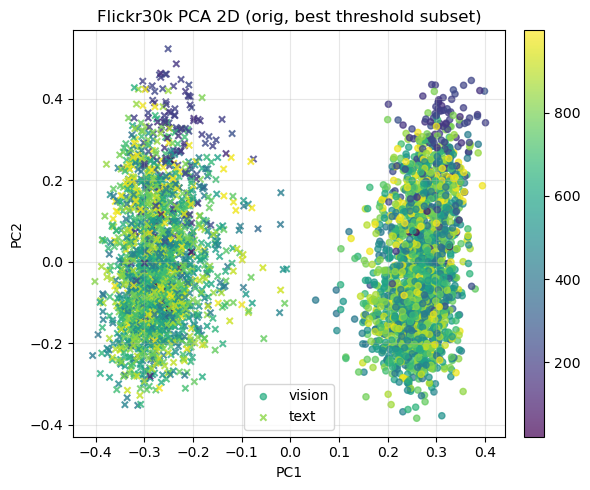

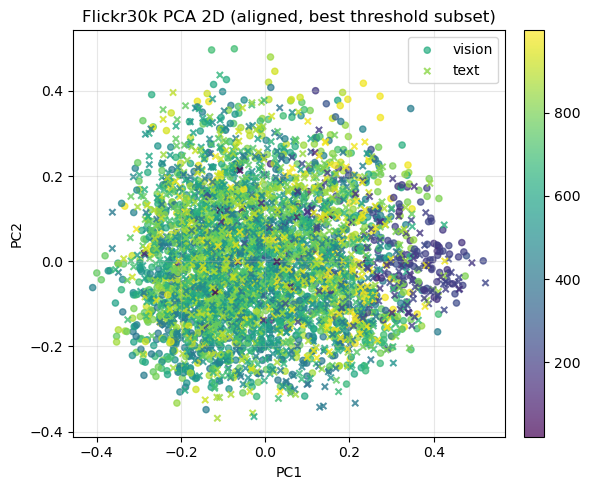

In [48]:
# PCA view for the best threshold selection on Flickr30k
def _collect_latent_for_plot_flickr30k(
    loader,
    idx,
    model,
    device="cuda",
    max_samples=4000,
):
    X_buf, Y_buf, Yal_buf, labels_buf = [], [], [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b, labels in tqdm(loader, desc="Collect Flickr30k for PCA"):
            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)
            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, model, renorm=True)

            Xs = X[:, idx]
            Ys = Y[:, idx]
            Yal_s = Yaln[:, idx]

            b = min(Xs.shape[0], max_samples - seen)
            if b <= 0:
                break

            X_buf.append(Xs[:b].detach().cpu())
            Y_buf.append(Ys[:b].detach().cpu())
            Yal_buf.append(Yal_s[:b].detach().cpu())
            labels_buf.append(labels[:b].detach().cpu())
            seen += b

            if seen >= max_samples:
                break

    X_all = torch.cat(X_buf, dim=0)
    Y_all = torch.cat(Y_buf, dim=0)
    Yal_all = torch.cat(Yal_buf, dim=0)
    labels_all = torch.cat(labels_buf, dim=0).numpy()
    return X_all, Y_all, Yal_all, labels_all

X_all_f, Y_all_f, Yal_all_f, labels_all_f = _collect_latent_for_plot_flickr30k(
    test_loader,
    best_idx_flickr30k,
    sub_model,
    device=device,
    max_samples=4000,
)

emb_orig_f = torch.cat([X_all_f, Y_all_f], dim=0).numpy()
emb_al_f = torch.cat([X_all_f, Yal_all_f], dim=0).numpy()
labels_2N_f = np.concatenate([labels_all_f, labels_all_f], axis=0)

_plot_pca_2d(
    emb_orig_f,
    labels_2N_f,
    title="Flickr30k PCA 2D (orig, best threshold subset)",
    max_points=4000,
)

_plot_pca_2d(
    emb_al_f,
    labels_2N_f,
    title="Flickr30k PCA 2D (aligned, best threshold subset)",
    max_points=4000,
)
